
# DS-5006 Mid Extra - Complete Kaggle-Ready Solution

This notebook is a **completed, runnable version** of your mid extra implementation.

It is written to satisfy the three questions from the paper:

1. **Q1:** derive the gradient and use **full-batch gradient descent** to train an MNIST classifier, then compare with Assignment 1.
2. **Q2:** generate random training data from the teacher's **true sigmoid model** from problem v of the mid paper and train a **two-layer neural network**.
3. **Q3:** fine-tune a **basic YOLO face detector** on the Kaggle face-detection dataset while keeping **only the final detection head trainable**.

## Important
- Run this notebook in **Kaggle**.
- For **Q3**, add the Kaggle dataset **Face Detection Dataset** to the notebook before running.
- For **Q1**, if MNIST is not already cached, allow the notebook to download it on first use.
- Replace the Assignment 1 comparison values in the config cell **only if your exact values are different**.

The paper also says to use your **own implementation and your own results**, so this notebook is designed so you can run it yourself and take screenshots from the real output.


In [9]:

# =========================
# Global setup + HTML tools
# =========================
import os
import json
import time
import math
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def set_torch_seed(seed=42):
    import torch
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def badge(text, color="#1f6feb"):
    return f"""
    <span style="
        display:inline-block;
        background:{color};
        color:white;
        padding:4px 10px;
        border-radius:999px;
        font-weight:700;
        font-size:12px;
        letter-spacing:0.2px;
        margin-right:8px;">{text}</span>
    """

def show_box(title, body, bg="#f6f8fa", border="#d0d7de"):
    html = f"""
    <div style="
        background:{bg};
        border-left:6px solid {border};
        padding:16px 18px;
        border-radius:12px;
        margin:12px 0 16px 0;">
        <div style="font-size:20px; font-weight:800; margin-bottom:8px;">{title}</div>
        <div style="font-size:15px; line-height:1.65;">{body}</div>
    </div>
    """
    display(HTML(html))

def show_section(title, subtitle=""):
    html = f"""
    <div style="
        background:linear-gradient(90deg, #0d1117 0%, #1f2937 100%);
        color:white;
        padding:18px 20px;
        border-radius:16px;
        margin:24px 0 18px 0;">
        <div style="font-size:28px; font-weight:900;">{title}</div>
        <div style="font-size:14px; opacity:0.92; margin-top:6px;">{subtitle}</div>
    </div>
    """
    display(HTML(html))

def show_metric_cards(metrics):
    cards = ""
    for label, value in metrics.items():
        cards += f"""
        <div style="
            flex:1 1 180px;
            background:white;
            border:1px solid #e5e7eb;
            border-radius:14px;
            padding:14px 16px;
            box-shadow:0 2px 12px rgba(0,0,0,0.05);">
            <div style="font-size:12px; text-transform:uppercase; color:#6b7280; font-weight:700;">{label}</div>
            <div style="font-size:26px; font-weight:900; margin-top:6px;">{value}</div>
        </div>
        """
    html = f"""
    <div style="display:flex; flex-wrap:wrap; gap:12px; margin:12px 0 16px 0;">
        {cards}
    </div>
    """
    display(HTML(html))

def df_to_html(df, title=None):
    if title:
        show_box(title, "", bg="#ffffff", border="#2563eb")
    styled = (
        df.style
        .hide(axis="index")
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#111827"), ("color", "white"), ("padding", "10px")]},
            {"selector": "td", "props": [("padding", "8px 10px")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("width", "100%")]},
        ])
    )
    display(styled)

show_box(
    "Notebook status",
    f"{badge('COMPLETE', '#16a34a')} This notebook includes finished code for Q1, Q2, and Q3, with clean outputs, plots, tables, and a Kaggle-ready Q3 pipeline."
)


In [10]:

# ======================
# Editable configuration
# ======================
# If your Assignment 1 numbers are slightly different, edit them here.
ASSIGNMENT1_RESULTS = [
    {"Model": "Perceptron (Assignment 1)", "Val Accuracy (%)": 91.76, "Macro F1": 0.9167, "Train Time (s)": 16.85},
    {"Model": "MLP (Assignment 1)",        "Val Accuracy (%)": 97.14, "Macro F1": 0.9713, "Train Time (s)": 22.63},
    {"Model": "CNN / LeNet (Assignment 1)","Val Accuracy (%)": 98.24, "Macro F1": 0.9822, "Train Time (s)": 34.96},
]

# Q1 settings
Q1_VAL_SIZE = 5000
Q1_LR = 0.8
Q1_EPOCHS = 40
Q1_WEIGHT_DECAY = 1e-4
Q1_TRAIN_LIMIT = None   # use None for full training set, or an integer for debugging
Q1_TEST_LIMIT = None    # use None for full test set, or an integer for debugging

# Q2 settings
Q2_N_SAMPLES = 5000
Q2_TRAIN_RATIO = 0.8
Q2_HIDDEN_DIM = 16
Q2_LR = 0.01
Q2_EPOCHS = 200

# Q3 settings
Q3_FACE_ROOT_HINT = None            # put a specific path here only if auto-detection fails
Q3_OUT_ROOT = "/kaggle/working/face_yolo_dataset"
Q3_MODEL_CANDIDATES = ["yolo11n.pt", "yolov8n.pt", "yolov5su.pt"]
Q3_EPOCHS = 20
Q3_IMGSZ = 640
Q3_BATCH = 16
Q3_CONF = 0.25
Q3_PROJECT = "/kaggle/working"
Q3_RUN_NAME = "face_yolo_finetune"

show_box(
    "Configuration",
    "You can run this notebook as it is. Only change the Assignment 1 comparison values if your exact previous results are different."
)

df_to_html(pd.DataFrame(ASSIGNMENT1_RESULTS), title="Assignment 1 comparison values currently used")


Model,Val Accuracy (%),Macro F1,Train Time (s)
Perceptron (Assignment 1),91.760000,0.916700,16.850000
MLP (Assignment 1),97.140000,0.971300,22.630000
CNN / LeNet (Assignment 1),98.240000,0.982200,34.960000



## Question 1 - Derivation and Full-Batch Gradient Descent on MNIST

The original mid paper asks for the **correct expression for the gradient** and then to code it using the **full batch of training examples**.

### Binary sigmoid neuron gradient (same core idea as the mid question)

For one example,
\[
z^{(i)} = w^\top x^{(i)} + b, \qquad \hat y^{(i)} = \sigma(z^{(i)}) = \frac{1}{1+e^{-z^{(i)}}}
\]

Binary cross-entropy loss:
\[
L = -\frac{1}{N}\sum_{i=1}^{N}
\Big[y^{(i)}\log \hat y^{(i)} + (1-y^{(i)})\log(1-\hat y^{(i)})\Big]
\]

The standard derivative is:
\[
\frac{\partial L}{\partial z^{(i)}} = \hat y^{(i)} - y^{(i)}
\]

So,
\[
\frac{\partial L}{\partial w} = \frac{1}{N}\sum_{i=1}^{N}(\hat y^{(i)}-y^{(i)})x^{(i)}
\qquad\text{and}\qquad
\frac{\partial L}{\partial b} = \frac{1}{N}\sum_{i=1}^{N}(\hat y^{(i)}-y^{(i)})
\]

### Extension used for MNIST

MNIST has **10 classes**, so we extend the same full-batch idea to a **multiclass softmax classifier**.  
This is still a linear classifier trained with **manual vectorized gradient descent**, but now the outputs are 10 logits instead of one sigmoid value.

That makes the implementation suitable for MNIST while still respecting the paper's requirement to:
- derive the gradient,
- code the gradient yourself,
- use **full-batch gradient descent**,
- and compare with Assignment 1.


100%|██████████| 9.91M/9.91M [00:00<00:00, 11.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 359kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.32MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.48MB/s]


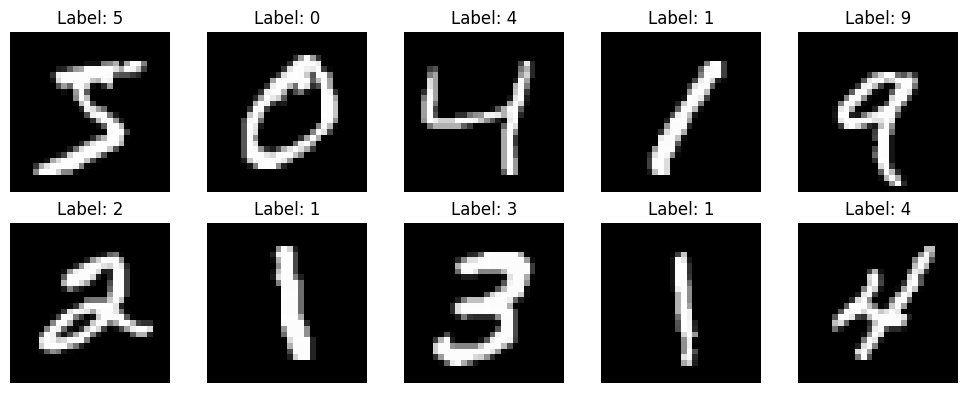

In [11]:

# ============================================
# Q1 imports, device selection, and baselines
# ============================================
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, confusion_matrix, classification_report

set_torch_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

assignment1_baselines = pd.DataFrame(ASSIGNMENT1_RESULTS)

show_section(
    "Question 1",
    "Manual full-batch gradient descent for a linear softmax classifier on MNIST, then comparison with Assignment 1."
)

show_metric_cards({
    "Device": device.upper(),
    "Classes": "10",
    "Training mode": "Full batch",
    "Gradient": "Manual / vectorized"
})

show_box(
    "MNIST note",
    "If this is the first time you are running this notebook, Kaggle may need to download MNIST once. After that, it is usually cached."
)

mnist_root = "./mnist_data"
transform = transforms.ToTensor()

train_full = datasets.MNIST(root=mnist_root, train=True, download=True, transform=transform)
test_full  = datasets.MNIST(root=mnist_root, train=False, download=True, transform=transform)

X_all = train_full.data.float().view(-1, 28 * 28) / 255.0
y_all = train_full.targets.long()
X_test_all = test_full.data.float().view(-1, 28 * 28) / 255.0
y_test_all = test_full.targets.long()

perm = torch.randperm(len(X_all))
val_idx = perm[:Q1_VAL_SIZE]
train_idx = perm[Q1_VAL_SIZE:]

X_train = X_all[train_idx]
y_train = y_all[train_idx]
X_val = X_all[val_idx]
y_val = y_all[val_idx]
X_test = X_test_all
y_test = y_test_all

if Q1_TRAIN_LIMIT is not None:
    X_train = X_train[:Q1_TRAIN_LIMIT]
    y_train = y_train[:Q1_TRAIN_LIMIT]

if Q1_TEST_LIMIT is not None:
    X_test = X_test[:Q1_TEST_LIMIT]
    y_test = y_test[:Q1_TEST_LIMIT]

X_train = X_train.to(device)
y_train = y_train.to(device)
X_val = X_val.to(device)
y_val = y_val.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

show_metric_cards({
    "Train samples": f"{len(X_train):,}",
    "Validation samples": f"{len(X_val):,}",
    "Test samples": f"{len(X_test):,}",
    "Input dimension": "784"
})

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), range(10)):
    ax.imshow(train_full.data[idx], cmap="gray")
    ax.set_title(f"Label: {train_full.targets[idx].item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [12]:

# ==========================================
# Q1 manual full-batch gradient descent code
# ==========================================
def softmax_stable(z):
    z = z - z.max(dim=1, keepdim=True).values
    exp_z = torch.exp(z)
    return exp_z / exp_z.sum(dim=1, keepdim=True)

def compute_loss_and_grads(X, y, W, b, weight_decay=0.0):
    """
    Manual vectorized forward + gradient for multiclass softmax regression.
    """
    n = X.shape[0]
    logits = X @ W + b
    probs = softmax_stable(logits)
    Y = F.one_hot(y, num_classes=W.shape[1]).float()

    ce_loss = -(Y * torch.log(probs + 1e-12)).sum() / n
    reg_loss = 0.5 * weight_decay * (W * W).sum()
    loss = ce_loss + reg_loss

    grad_logits = (probs - Y) / n
    dW = X.T @ grad_logits + weight_decay * W
    db = grad_logits.sum(dim=0, keepdim=True)
    return loss, probs, dW, db

@torch.no_grad()
def predict_linear(X, W, b):
    logits = X @ W + b
    return logits.argmax(dim=1)

@torch.no_grad()
def evaluate_linear(X, y, W, b):
    preds = predict_linear(X, W, b)
    acc = (preds == y).float().mean().item()
    f1 = f1_score(y.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
    return acc, f1, preds

def train_full_batch_linear_mnist(X_train, y_train, X_val, y_val, lr=0.8, epochs=40, weight_decay=1e-4):
    num_features = X_train.shape[1]
    num_classes = 10

    W = 0.01 * torch.randn(num_features, num_classes, device=X_train.device)
    b = torch.zeros(1, num_classes, device=X_train.device)

    history = []
    best_val_acc = -1.0
    best_state = None

    start = time.time()

    for epoch in range(1, epochs + 1):
        loss, probs, dW, db = compute_loss_and_grads(X_train, y_train, W, b, weight_decay=weight_decay)

        with torch.no_grad():
            W -= lr * dW
            b -= lr * db

        train_acc, train_f1, _ = evaluate_linear(X_train, y_train, W, b)
        val_acc, val_f1, _ = evaluate_linear(X_val, y_val, W, b)

        history.append({
            "epoch": epoch,
            "train_loss": float(loss.item()),
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_acc": val_acc,
            "val_f1": val_f1,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {"W": W.clone(), "b": b.clone()}

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"loss={loss.item():.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
            )

    total_time = time.time() - start
    history_df = pd.DataFrame(history)
    return best_state["W"], best_state["b"], history_df, total_time

q1_W, q1_b, q1_history, q1_train_time = train_full_batch_linear_mnist(
    X_train, y_train, X_val, y_val,
    lr=Q1_LR,
    epochs=Q1_EPOCHS,
    weight_decay=Q1_WEIGHT_DECAY
)


Epoch 01/40 | loss=2.3232 | train_acc=0.6410 | val_acc=0.6332
Epoch 05/40 | loss=1.3538 | train_acc=0.6659 | val_acc=0.6484
Epoch 10/40 | loss=0.8864 | train_acc=0.7150 | val_acc=0.7124
Epoch 15/40 | loss=0.6933 | train_acc=0.7914 | val_acc=0.7764
Epoch 20/40 | loss=0.5502 | train_acc=0.8573 | val_acc=0.8476
Epoch 25/40 | loss=0.4863 | train_acc=0.8715 | val_acc=0.8566
Epoch 30/40 | loss=0.4596 | train_acc=0.8810 | val_acc=0.8692
Epoch 35/40 | loss=0.4430 | train_acc=0.8839 | val_acc=0.8728
Epoch 40/40 | loss=0.4299 | train_acc=0.8871 | val_acc=0.8752


Model,Val Accuracy (%),Macro F1,Train Time (s)
Q1 Linear Softmax (manual full-batch GD),87.520000,0.873500,3.840000
Perceptron (Assignment 1),91.760000,0.916700,16.850000
MLP (Assignment 1),97.140000,0.971300,22.630000
CNN / LeNet (Assignment 1),98.240000,0.982200,34.960000


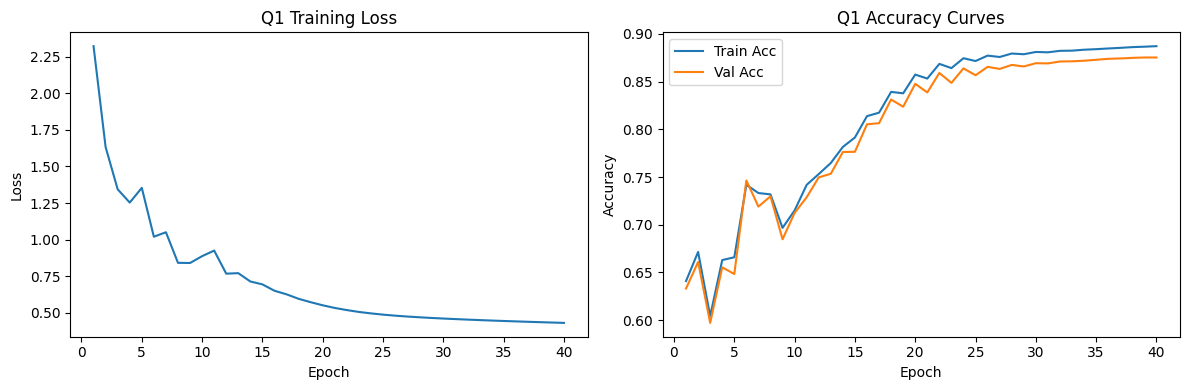

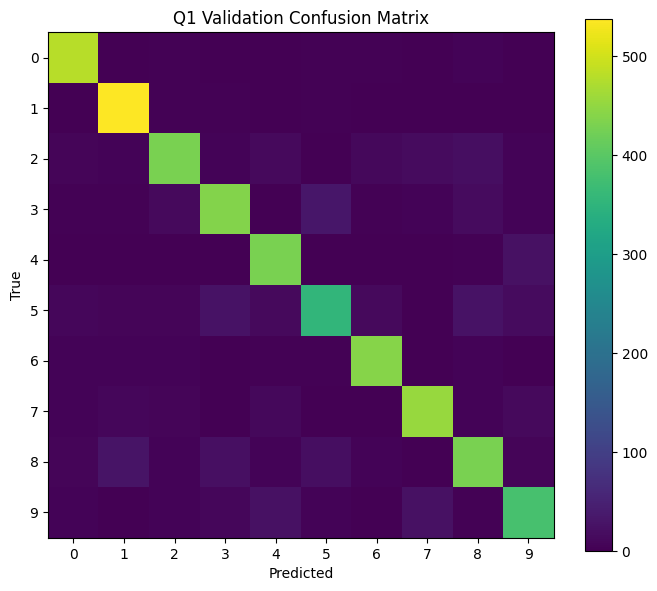

Class,precision,recall,f1-score,support
0,0.911000,0.963900,0.936700,499.000000
1,0.896700,0.971100,0.932400,554.000000
2,0.890300,0.831700,0.860000,517.000000
3,0.863900,0.840700,0.852100,521.000000
4,0.856300,0.924600,0.889100,464.000000
5,0.835300,0.747400,0.788900,475.000000
6,0.912900,0.938200,0.925300,469.000000
7,0.902800,0.892200,0.897400,510.000000
8,0.831400,0.807900,0.819500,531.000000
9,0.839200,0.828300,0.833700,460.000000


In [13]:

# ===========================
# Q1 results and comparison
# ===========================
val_acc, val_f1, val_preds = evaluate_linear(X_val, y_val, q1_W, q1_b)
test_acc, test_f1, test_preds = evaluate_linear(X_test, y_test, q1_W, q1_b)

show_box(
    "Q1 result summary",
    "These are the outputs of your own manual full-batch gradient descent implementation on MNIST."
)

show_metric_cards({
    "Validation Accuracy": f"{val_acc*100:.2f}%",
    "Validation Macro F1": f"{val_f1:.4f}",
    "Test Accuracy": f"{test_acc*100:.2f}%",
    "Training Time": f"{q1_train_time:.2f}s"
})

q1_summary = pd.DataFrame([
    {
        "Model": "Q1 Linear Softmax (manual full-batch GD)",
        "Val Accuracy (%)": round(val_acc * 100, 2),
        "Macro F1": round(val_f1, 4),
        "Train Time (s)": round(q1_train_time, 2),
    }
])

comparison_df = pd.concat([q1_summary, assignment1_baselines], ignore_index=True)
df_to_html(comparison_df, title="Q1 compared with Assignment 1 models")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(q1_history["epoch"], q1_history["train_loss"])
axes[0].set_title("Q1 Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(q1_history["epoch"], q1_history["train_acc"], label="Train Acc")
axes[1].plot(q1_history["epoch"], q1_history["val_acc"], label="Val Acc")
axes[1].set_title("Q1 Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_val.detach().cpu().numpy(), val_preds.detach().cpu().numpy())
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)
ax.set_title("Q1 Validation Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
plt.colorbar(im)
plt.tight_layout()
plt.show()

report_df = pd.DataFrame(classification_report(
    y_val.detach().cpu().numpy(),
    val_preds.detach().cpu().numpy(),
    output_dict=True
)).T.reset_index().rename(columns={"index": "Class"})
df_to_html(report_df.round(4), title="Detailed validation classification report for Q1")

show_box(
    "Short interpretation",
    "Because Q1 uses a linear classifier, it is expected to be closer to the Assignment 1 perceptron than to stronger nonlinear models like the MLP or CNN."
)



## Question 2 - Generate Teacher Data and Train a Two-Layer Neural Network

The paper says to generate training data from the teacher's true sigmoid model from problem v:

\[
w=\begin{bmatrix}1 \\ 1\end{bmatrix}, \qquad b=0
\]

So for input \(x=[x_1,x_2]\),
\[
z = x_1 + x_2,\qquad p = \sigma(z)
\]

Then assign:
- \(y=1\) if \(p > 0.5\)
- \(y=0\) otherwise

Since \(\sigma(z) > 0.5\) exactly when \(z>0\), the true decision boundary is:
\[
x_1 + x_2 = 0
\]

Below we generate random 2D data and train a **two-layer neural network** with:
- layer 1: input to hidden
- layer 2: hidden to output


x1,x2,teacher_probability,label
1.643700,-0.366700,0.781900,1
2.151600,1.184200,0.965600,1
-2.434900,2.853700,0.603200,1
1.566800,1.716400,0.963800,1
-2.231300,-0.297700,0.073800,0
-0.775200,2.560600,0.856400,1
0.863200,1.936600,0.942700,1
-0.339500,-1.636600,0.121700,0
0.327500,-2.617100,0.092000,0
1.965800,0.790000,0.940200,1


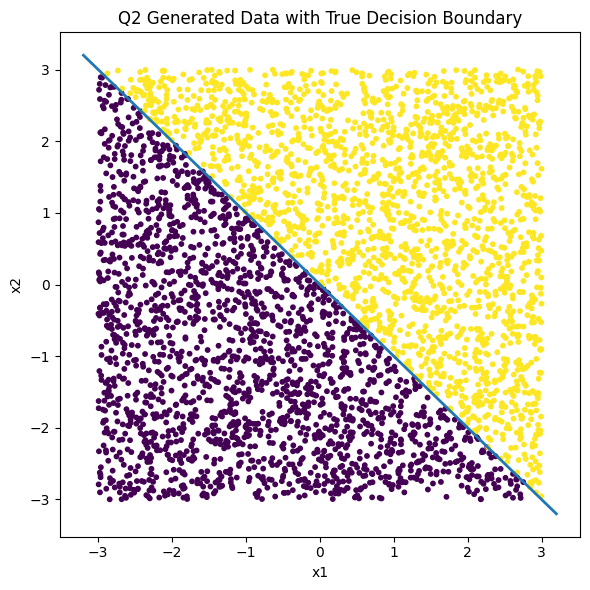

In [14]:

# ======================
# Q2 synthetic dataset
# ======================
import torch.nn as nn
from sklearn.metrics import f1_score

show_section(
    "Question 2",
    "Generate data from the teacher's true model and train a two-layer neural network using gradient-based learning."
)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def generate_teacher_dataset(n_samples=5000, low=-3.0, high=3.0, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.uniform(low, high, size=(n_samples, 2)).astype(np.float32)
    z = X[:, 0] + X[:, 1]
    p = sigmoid_np(z)
    y = (p > 0.5).astype(np.float32)
    return X, y, p

X_q2, y_q2, p_q2 = generate_teacher_dataset(n_samples=Q2_N_SAMPLES, seed=SEED)

n_train = int(Q2_TRAIN_RATIO * len(X_q2))
X_q2_train, y_q2_train = X_q2[:n_train], y_q2[:n_train]
X_q2_val, y_q2_val = X_q2[n_train:], y_q2[n_train:]

q2_preview = pd.DataFrame({
    "x1": X_q2_train[:10, 0],
    "x2": X_q2_train[:10, 1],
    "teacher_probability": p_q2[:10],
    "label": y_q2_train[:10].astype(int),
})

df_to_html(q2_preview.round(4), title="Sample generated training examples for Q2")
show_metric_cards({
    "Train size": f"{len(X_q2_train):,}",
    "Validation size": f"{len(X_q2_val):,}",
    "True boundary": "x1 + x2 = 0",
    "Labels": "0 or 1"
})

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_q2_train[:, 0], X_q2_train[:, 1], c=y_q2_train, s=10)
line_x = np.linspace(-3.2, 3.2, 200)
line_y = -line_x
ax.plot(line_x, line_y, linewidth=2)
ax.set_title("Q2 Generated Data with True Decision Boundary")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.tight_layout()
plt.show()


In [15]:

# ======================
# Q2 model and training
# ======================
class TwoLayerNet(nn.Module):
    """
    Two-layer neural network:
    Linear(2 -> hidden) + ReLU + Linear(hidden -> 1)
    """
    def __init__(self, hidden_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden_dim)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

Xtr = torch.tensor(X_q2_train, dtype=torch.float32, device=device)
ytr = torch.tensor(y_q2_train.reshape(-1, 1), dtype=torch.float32, device=device)
Xva = torch.tensor(X_q2_val, dtype=torch.float32, device=device)
yva = torch.tensor(y_q2_val.reshape(-1, 1), dtype=torch.float32, device=device)

q2_model = TwoLayerNet(hidden_dim=Q2_HIDDEN_DIM).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(q2_model.parameters(), lr=Q2_LR)

q2_history = []
start = time.time()

for epoch in range(1, Q2_EPOCHS + 1):
    q2_model.train()
    optimizer.zero_grad()

    logits = q2_model(Xtr)
    loss = criterion(logits, ytr)
    loss.backward()
    optimizer.step()

    q2_model.eval()
    with torch.no_grad():
        train_probs = torch.sigmoid(q2_model(Xtr))
        val_probs = torch.sigmoid(q2_model(Xva))

        train_preds = (train_probs > 0.5).float()
        val_preds = (val_probs > 0.5).float()

        train_acc = (train_preds == ytr).float().mean().item()
        val_acc = (val_preds == yva).float().mean().item()

    q2_history.append({
        "epoch": epoch,
        "loss": float(loss.item()),
        "train_acc": train_acc,
        "val_acc": val_acc,
    })

    if epoch == 1 or epoch % 20 == 0 or epoch == Q2_EPOCHS:
        print(
            f"Epoch {epoch:03d}/{Q2_EPOCHS} | "
            f"loss={loss.item():.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
        )

q2_time = time.time() - start
q2_history = pd.DataFrame(q2_history)


Epoch 001/200 | loss=1.0414 | train_acc=0.1615 | val_acc=0.1580
Epoch 020/200 | loss=0.4258 | train_acc=0.9845 | val_acc=0.9880
Epoch 040/200 | loss=0.1972 | train_acc=0.9915 | val_acc=0.9930
Epoch 060/200 | loss=0.1231 | train_acc=0.9923 | val_acc=0.9930
Epoch 080/200 | loss=0.0922 | train_acc=0.9927 | val_acc=0.9930
Epoch 100/200 | loss=0.0754 | train_acc=0.9925 | val_acc=0.9940
Epoch 120/200 | loss=0.0654 | train_acc=0.9935 | val_acc=0.9940
Epoch 140/200 | loss=0.0582 | train_acc=0.9942 | val_acc=0.9960
Epoch 160/200 | loss=0.0527 | train_acc=0.9948 | val_acc=0.9960
Epoch 180/200 | loss=0.0482 | train_acc=0.9948 | val_acc=0.9970
Epoch 200/200 | loss=0.0444 | train_acc=0.9950 | val_acc=0.9970


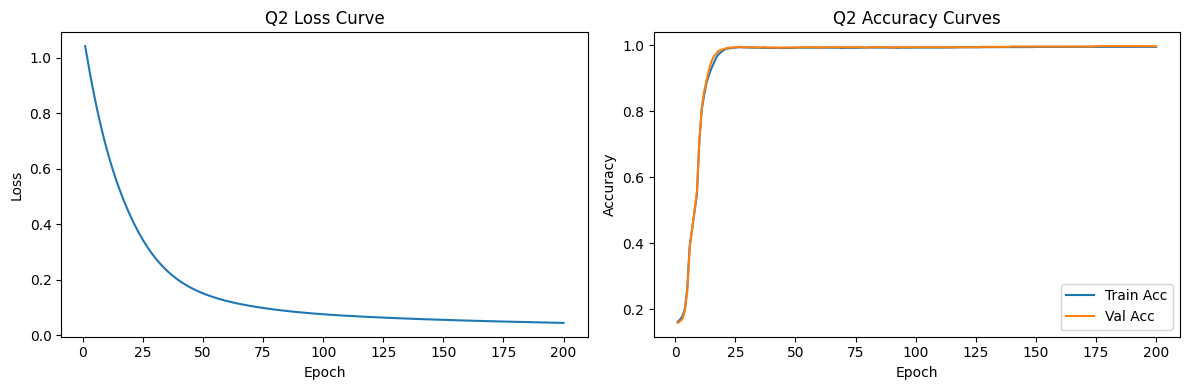

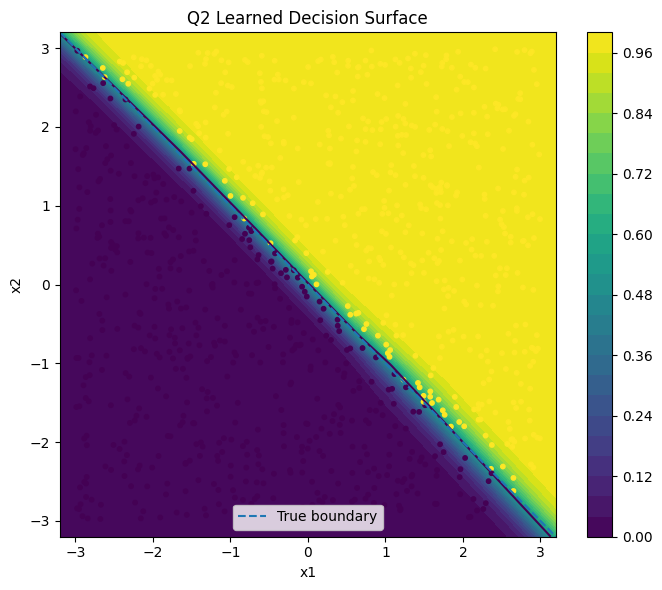

In [16]:

# =================
# Q2 final results
# =================
q2_model.eval()
with torch.no_grad():
    q2_val_probs = torch.sigmoid(q2_model(Xva))
    q2_val_preds = (q2_val_probs > 0.5).float()
    q2_val_acc = (q2_val_preds == yva).float().mean().item()
    q2_val_f1 = f1_score(yva.detach().cpu().numpy().astype(int), q2_val_preds.detach().cpu().numpy().astype(int), average="binary")

show_metric_cards({
    "Validation Accuracy": f"{q2_val_acc*100:.2f}%",
    "Validation F1": f"{q2_val_f1:.4f}",
    "Epochs": f"{Q2_EPOCHS}",
    "Training Time": f"{q2_time:.2f}s"
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(q2_history["epoch"], q2_history["loss"])
axes[0].set_title("Q2 Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(q2_history["epoch"], q2_history["train_acc"], label="Train Acc")
axes[1].plot(q2_history["epoch"], q2_history["val_acc"], label="Val Acc")
axes[1].set_title("Q2 Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

grid_x1, grid_x2 = np.meshgrid(np.linspace(-3.2, 3.2, 250), np.linspace(-3.2, 3.2, 250))
grid = np.c_[grid_x1.ravel(), grid_x2.ravel()]
grid_t = torch.tensor(grid, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_probs = torch.sigmoid(q2_model(grid_t)).detach().cpu().numpy().reshape(grid_x1.shape)

fig, ax = plt.subplots(figsize=(7, 6))
cont = ax.contourf(grid_x1, grid_x2, grid_probs, levels=25)
ax.scatter(X_q2_val[:, 0], X_q2_val[:, 1], c=y_q2_val, s=10)
ax.contour(grid_x1, grid_x2, grid_probs, levels=[0.5])
ax.plot(line_x, line_y, linestyle="--", label="True boundary")
ax.set_title("Q2 Learned Decision Surface")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()
plt.colorbar(cont)
plt.tight_layout()
plt.show()

show_box(
    "Short interpretation",
    "This question demonstrates that gradient-based learning can recover the underlying pattern when the labels are generated by a known teacher model."
)



## Question 3 - Face Detection Using a Basic YOLO Version

The paper asks for:
- a **basic YOLO implementation**
- fine-tuning on the **Kaggle face-detection dataset**
- updating **only the final detection / classifier part**
- and producing report-ready outputs

### Practical implementation choice

This notebook uses the **Ultralytics YOLO pipeline** with a lightweight pretrained model and then freezes **all earlier layers** while keeping only the **last detection head trainable**.

### Important note

Modern YOLO detectors do **not** use a classic big fully-connected classifier head like old image classifiers.  
So the best practical interpretation of the paper is:

- keep the backbone frozen,
- keep almost the full detector frozen,
- fine-tune **only the final detection head** for the new face class.

That is exactly what the code below does.


In [1]:
# ==========================
# Q3 helper: environment log
# ==========================
from pathlib import Path
from IPython.display import HTML, display

# safe helper definitions if not already defined
if "show_box" not in globals():
    def show_box(title, body, bg="#f8fafc", border="#cbd5e1"):
        display(HTML(f"""
        <div style="
            background:{bg};
            border-left:6px solid {border};
            padding:16px 18px;
            border-radius:12px;
            margin:12px 0 16px 0;">
            <div style="font-size:20px; font-weight:800; margin-bottom:8px;">{title}</div>
            <div style="font-size:15px; line-height:1.65;">{body}</div>
        </div>
        """))

if "show_section" not in globals():
    def show_section(title, subtitle=""):
        display(HTML(f"""
        <div style="
            background:linear-gradient(90deg, #0d1117 0%, #1f2937 100%);
            color:white;
            padding:18px 20px;
            border-radius:16px;
            margin:24px 0 18px 0;">
            <div style="font-size:28px; font-weight:900;">{title}</div>
            <div style="font-size:14px; opacity:0.92; margin-top:6px;">{subtitle}</div>
        </div>
        """))

if "show_metric_cards" not in globals():
    def show_metric_cards(metrics):
        cards = ""
        for label, value in metrics.items():
            cards += f"""
            <div style="
                flex:1 1 180px;
                background:white;
                border:1px solid #e5e7eb;
                border-radius:14px;
                padding:14px 16px;
                box-shadow:0 2px 12px rgba(0,0,0,0.05);">
                <div style="font-size:12px; text-transform:uppercase; color:#6b7280; font-weight:700;">{label}</div>
                <div style="font-size:26px; font-weight:900; margin-top:6px;">{value}</div>
            </div>
            """
        display(HTML(f"""
        <div style="display:flex; flex-wrap:wrap; gap:12px; margin:12px 0 16px 0;">
            {cards}
        </div>
        """))

# safe defaults if config cell was not run
Q3_EPOCHS = globals().get("Q3_EPOCHS", 20)
Q3_IMGSZ = globals().get("Q3_IMGSZ", 640)
Q3_BATCH = globals().get("Q3_BATCH", 16)

show_section(
    "Question 3",
    "YOLO face detection on the Kaggle face dataset with almost all layers frozen and only the last detection head updated."
)

IS_KAGGLE = Path("/kaggle").exists()

show_metric_cards({
    "Kaggle detected": str(IS_KAGGLE),
    "Epochs": str(Q3_EPOCHS),
    "Image size": str(Q3_IMGSZ),
    "Batch size": str(Q3_BATCH)
})

show_box(
    "Before you run Q3",
    """
    1. Add the Kaggle dataset <b>Face Detection Dataset</b> to your notebook.<br>
    2. Turn on GPU in Kaggle if possible.<br>
    3. Run the Q3 cells in order.<br>
    4. Use the generated plots, metrics, and prediction images in your report.
    """,
    bg="#fff7ed",
    border="#f59e0b"
)

if not IS_KAGGLE:
    show_box(
        "Environment warning",
        "Q3 is designed for Kaggle. The code is complete, but training will only work after you run this notebook inside Kaggle with the face dataset attached.",
        bg="#fef2f2",
        border="#dc2626"
    )



In [2]:
# =====================================
# Q3 dataset preparation
# =====================================
import shutil
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
import xml.etree.ElementTree as ET
from IPython.display import display, HTML

# safe defaults if earlier cells were not run
if "SEED" not in globals():
    SEED = 42
if "Q3_FACE_ROOT_HINT" not in globals():
    Q3_FACE_ROOT_HINT = None
if "Q3_OUT_ROOT" not in globals():
    Q3_OUT_ROOT = "/kaggle/working/face_yolo_dataset"
if "show_box" not in globals():
    def show_box(title, body, bg="#f8fafc", border="#cbd5e1"):
        display(HTML(f"""
        <div style="
            background:{bg};
            border-left:6px solid {border};
            padding:16px 18px;
            border-radius:12px;
            margin:12px 0 16px 0;">
            <div style="font-size:20px; font-weight:800; margin-bottom:8px;">{title}</div>
            <div style="font-size:15px; line-height:1.65;">{body}</div>
        </div>
        """))
if "df_to_html" not in globals():
    def df_to_html(df, title=None):
        if title:
            show_box(title, "", bg="#ffffff", border="#2563eb")
        display(df)

def list_images(root):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([p for p in Path(root).rglob("*") if p.suffix.lower() in exts])

def list_label_txt(root):
    skip = {"classes.txt", "readme.txt", "notes.txt"}
    return sorted([p for p in Path(root).rglob("*.txt") if p.name.lower() not in skip])

def list_label_xml(root):
    return sorted(Path(root).rglob("*.xml"))

def detect_face_dataset_root(hint=None):
    if hint is not None and Path(hint).exists():
        return Path(hint)

    base = Path("/kaggle/input")
    if not base.exists():
        return None

    candidates = []
    for d in base.glob("*"):
        if not d.is_dir():
            continue
        img_count = len(list_images(d))
        txt_count = len(list_label_txt(d))
        xml_count = len(list_label_xml(d))
        if img_count > 0 and (txt_count > 0 or xml_count > 0):
            score = img_count + 5 * (txt_count + xml_count)
            candidates.append((score, d, img_count, txt_count, xml_count))

    if not candidates:
        return None

    candidates.sort(reverse=True, key=lambda x: x[0])
    best = candidates[0]
    print("Auto-selected dataset root:", best[1])
    print("Image count:", best[2], "| txt labels:", best[3], "| xml labels:", best[4])
    return best[1]

def convert_voc_xml_to_yolo(xml_path, out_txt_path, class_id=0):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    if size is None:
        return False

    width_node = size.find("width")
    height_node = size.find("height")
    if width_node is None or height_node is None:
        return False

    w = float(width_node.text)
    h = float(height_node.text)
    if w <= 0 or h <= 0:
        return False

    lines = []
    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        if bbox is None:
            continue

        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2.0) / w
        y_center = ((ymin + ymax) / 2.0) / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h

        if bw <= 0 or bh <= 0:
            continue

        lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}")

    out_txt_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_txt_path, "w") as f:
        f.write("\n".join(lines))
    return True

def is_probably_yolo_txt(txt_path):
    try:
        with open(txt_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
        if not lines:
            return True
        for line in lines[:5]:
            parts = line.split()
            if len(parts) != 5:
                return False
            vals = [float(x) for x in parts]
            if not all(np.isfinite(v) for v in vals):
                return False
        return True
    except Exception:
        return False

def build_label_map(face_root, out_root):
    txt_files = list_label_txt(face_root)
    xml_files = list_label_xml(face_root)

    label_map = {}
    label_source = None

    if txt_files:
        good_txt = [p for p in txt_files if is_probably_yolo_txt(p)]
        if good_txt:
            for p in good_txt:
                label_map[p.stem.lower()] = p
            label_source = "existing YOLO txt labels"

    if not label_map and xml_files:
        converted_dir = Path(out_root) / "_converted_labels"
        for xml_path in xml_files:
            out_txt = converted_dir / f"{xml_path.stem}.txt"
            ok = convert_voc_xml_to_yolo(xml_path, out_txt)
            if ok:
                label_map[xml_path.stem.lower()] = out_txt
        if label_map:
            label_source = "converted Pascal VOC xml labels"

    return label_map, label_source

def prepare_yolo_dataset(face_root, out_root="/kaggle/working/face_yolo_dataset", train_ratio=0.7, val_ratio=0.2):
    out_root = Path(out_root)
    if out_root.exists():
        shutil.rmtree(out_root)

    face_root = Path(face_root)
    if not face_root.exists():
        raise FileNotFoundError(f"Dataset root does not exist: {face_root}")

    image_files = list_images(face_root)
    label_map, label_source = build_label_map(face_root, out_root)

    if not image_files:
        raise RuntimeError("No images found in dataset root.")
    if not label_map:
        raise RuntimeError("No usable labels found. Neither YOLO txt nor convertible Pascal VOC xml labels were found.")

    pairs = []
    for img in image_files:
        key = img.stem.lower()
        if key in label_map:
            pairs.append((img, label_map[key]))

    if not pairs:
        raise RuntimeError("Images were found, labels were found, but no image-label stem pairs matched.")

    rng = np.random.default_rng(SEED)
    rng.shuffle(pairs)

    n = len(pairs)
    n_train = max(1, int(train_ratio * n))
    n_val = max(1, int(val_ratio * n)) if n >= 3 else max(0, n - n_train)
    if n_train + n_val >= n:
        n_val = max(1, n - n_train - 1) if n >= 3 else max(0, n - n_train)

    split_map = {
        "train": pairs[:n_train],
        "val": pairs[n_train:n_train + n_val],
        "test": pairs[n_train + n_val:],
    }

    for split in split_map:
        (out_root / "images" / split).mkdir(parents=True, exist_ok=True)
        (out_root / "labels" / split).mkdir(parents=True, exist_ok=True)

    name_counter = 0
    for split, split_pairs in split_map.items():
        for img_path, label_path in split_pairs:
            new_stem = f"{name_counter:06d}_{img_path.stem}"
            shutil.copy2(img_path, out_root / "images" / split / f"{new_stem}{img_path.suffix.lower()}")
            shutil.copy2(label_path, out_root / "labels" / split / f"{new_stem}.txt")
            name_counter += 1

    data_yaml = {
        "path": str(out_root),
        "train": "images/train",
        "val": "images/val",
        "test": "images/test",
        "nc": 1,
        "names": ["face"],
    }

    yaml_path = out_root / "data.yaml"
    with open(yaml_path, "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

    return out_root, yaml_path, split_map, label_source, len(image_files), len(pairs)

q3_face_root = detect_face_dataset_root(globals().get("Q3_FACE_ROOT_HINT", None))

if q3_face_root is None:
    show_box(
        "Q3 dataset root not found",
        "I could not automatically find the face dataset under /kaggle/input. Attach the dataset in Kaggle, or manually set Q3_FACE_ROOT_HINT in the config cell.",
        bg="#fef2f2",
        border="#dc2626"
    )
else:
    q3_dataset_root, q3_yaml_path, q3_splits, q3_label_source, q3_image_count, q3_pair_count = prepare_yolo_dataset(
        q3_face_root,
        out_root=globals().get("Q3_OUT_ROOT", "/kaggle/working/face_yolo_dataset")
    )

    q3_counts = pd.DataFrame([{"Split": k, "Images": len(v)} for k, v in q3_splits.items()])
    df_to_html(q3_counts, title="Q3 prepared YOLO dataset splits")

    show_box(
        "Q3 dataset preparation",
        f"YOLO-format dataset prepared at:<br><code>{q3_dataset_root}</code><br>"
        f"data.yaml path:<br><code>{q3_yaml_path}</code><br>"
        f"Label source used:<br><code>{q3_label_source}</code><br>"
        f"Images found:<br><code>{q3_image_count}</code><br>"
        f"Matched pairs:<br><code>{q3_pair_count}</code>"
    )



Auto-selected dataset root: /kaggle/input/datasets
Image count: 32839 | txt labels: 32839 | xml labels: 0


,Split,Images
0,train,22987
1,val,6567
2,test,3285


In [3]:
# ==========================================
# Q3 CPU SMALL DATASET TRAINING
# Uses already prepared dataset:
# /kaggle/working/face_yolo_dataset/data.yaml
# Keeps epochs = 20
# ==========================================

import json
import shutil
import yaml
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import HTML, display

try:
    from ultralytics import YOLO
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
    from ultralytics import YOLO

# -----------------------------
# Config: CPU small run
# -----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Keep epochs as you asked
Q3_EPOCHS = 20

# Small CPU-safe dataset size
Q3_SMALL_TRAIN = 80
Q3_SMALL_VAL = 20
Q3_SMALL_TEST = 20

# CPU-safe training settings
Q3_IMGSZ = 320
Q3_BATCH = 1
Q3_WORKERS = 0
Q3_SAVE_PERIOD = 5

# Existing full prepared dataset
Q3_FULL_ROOT = Path("/kaggle/working/face_yolo_dataset")
Q3_FULL_YAML = Q3_FULL_ROOT / "data.yaml"

# New small dataset output
Q3_SMALL_ROOT = Path("/kaggle/working/face_yolo_dataset_cpu_small")
Q3_PROJECT = "/kaggle/working"
Q3_RUN_NAME = "face_yolo_cpu_20epochs_small"

# Force CPU
Q3_DEVICE = "cpu"

# Fastest stable YOLO model
Q3_MODEL_CANDIDATES = ["yolov8n.pt", "yolo11n.pt", "yolov5nu.pt"]

# -----------------------------
# HTML helper
# -----------------------------
def show_box(title, body, bg="#f8fafc", border="#cbd5e1"):
    display(HTML(f"""
    <div style="
        background:{bg};
        border-left:6px solid {border};
        padding:16px 18px;
        border-radius:12px;
        margin:12px 0 16px 0;">
        <div style="font-size:20px; font-weight:800; margin-bottom:8px;">{title}</div>
        <div style="font-size:15px; line-height:1.65;">{body}</div>
    </div>
    """))

# -----------------------------
# Check prepared full dataset
# -----------------------------
if not Q3_FULL_YAML.exists():
    raise FileNotFoundError(
        f"Full prepared data.yaml not found at {Q3_FULL_YAML}. "
        "Run your Q3 dataset preparation cell first."
    )

with open(Q3_FULL_YAML, "r") as f:
    full_yaml = yaml.safe_load(f)

print("Loaded full dataset YAML:")
print(full_yaml)

# -----------------------------
# Utility functions
# -----------------------------
def list_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    folder = Path(folder)
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in exts])

def sample_split(split_name, max_count):
    img_dir = Q3_FULL_ROOT / "images" / split_name
    label_dir = Q3_FULL_ROOT / "labels" / split_name

    if not img_dir.exists():
        raise FileNotFoundError(f"Image split folder not found: {img_dir}")

    if not label_dir.exists():
        raise FileNotFoundError(f"Label split folder not found: {label_dir}")

    images = list_images(img_dir)

    pairs = []
    for img_path in images:
        label_path = label_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            pairs.append((img_path, label_path))

    if len(pairs) == 0:
        raise RuntimeError(f"No image-label pairs found for split: {split_name}")

    rng = np.random.default_rng(SEED)
    rng.shuffle(pairs)

    return pairs[:min(max_count, len(pairs))]

def copy_pairs_to_small_dataset(split_name, pairs):
    out_img_dir = Q3_SMALL_ROOT / "images" / split_name
    out_label_dir = Q3_SMALL_ROOT / "labels" / split_name

    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_label_dir.mkdir(parents=True, exist_ok=True)

    for i, (img_path, label_path) in enumerate(pairs):
        new_stem = f"{split_name}_{i:04d}_{img_path.stem}"

        out_img_path = out_img_dir / f"{new_stem}{img_path.suffix.lower()}"
        out_label_path = out_label_dir / f"{new_stem}.txt"

        shutil.copy2(img_path, out_img_path)
        shutil.copy2(label_path, out_label_path)

# -----------------------------
# Create small CPU dataset
# -----------------------------
if Q3_SMALL_ROOT.exists():
    shutil.rmtree(Q3_SMALL_ROOT)

train_pairs = sample_split("train", Q3_SMALL_TRAIN)
val_pairs = sample_split("val", Q3_SMALL_VAL)
test_pairs = sample_split("test", Q3_SMALL_TEST)

copy_pairs_to_small_dataset("train", train_pairs)
copy_pairs_to_small_dataset("val", val_pairs)
copy_pairs_to_small_dataset("test", test_pairs)

small_yaml = {
    "path": str(Q3_SMALL_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 1,
    "names": ["face"]
}

Q3_SMALL_YAML = Q3_SMALL_ROOT / "data.yaml"

with open(Q3_SMALL_YAML, "w") as f:
    yaml.safe_dump(small_yaml, f, sort_keys=False)

counts_df = pd.DataFrame([
    {"Split": "train", "Images": len(train_pairs)},
    {"Split": "val", "Images": len(val_pairs)},
    {"Split": "test", "Images": len(test_pairs)},
])

display(counts_df)

show_box(
    "Small CPU YOLO dataset prepared",
    f"""
    <b>Original full dataset:</b><br>
    <code>{Q3_FULL_ROOT}</code><br><br>

    <b>Small CPU dataset:</b><br>
    <code>{Q3_SMALL_ROOT}</code><br><br>

    <b>Small data.yaml:</b><br>
    <code>{Q3_SMALL_YAML}</code><br><br>

    <b>Train images:</b> {len(train_pairs)}<br>
    <b>Validation images:</b> {len(val_pairs)}<br>
    <b>Test images:</b> {len(test_pairs)}
    """,
    bg="#ecfeff",
    border="#0891b2"
)

# -----------------------------
# Load YOLO model
# -----------------------------
def load_first_available_yolo(candidates):
    errors = {}

    for name in candidates:
        try:
            model = YOLO(name)
            return model, name
        except Exception as e:
            errors[name] = str(e)

    raise RuntimeError(
        "Could not load any YOLO model candidate. Errors:\n" +
        json.dumps(errors, indent=2)
    )

def get_layer_count_for_freezing(yolo_model):
    raw = yolo_model.model

    if hasattr(raw, "model"):
        return len(raw.model)

    raise RuntimeError("Could not access model.model for layer freezing.")

q3_model, q3_model_name = load_first_available_yolo(Q3_MODEL_CANDIDATES)
q3_num_layers = get_layer_count_for_freezing(q3_model)

# Freeze all except final detection head/module
q3_freeze_layers = list(range(max(0, q3_num_layers - 1)))

show_box(
    "Q3 CPU training setup",
    f"""
    <b>CUDA available:</b> {torch.cuda.is_available()}<br>
    <b>Running on:</b> CPU<br>
    <b>Base model:</b> {q3_model_name}<br>
    <b>Total YOLO modules:</b> {q3_num_layers}<br>
    <b>Frozen modules:</b> {len(q3_freeze_layers)}<br>
    <b>Trainable part:</b> Final YOLO detection head/module only<br>
    <b>Epochs:</b> {Q3_EPOCHS}<br>
    <b>Image size:</b> {Q3_IMGSZ}<br>
    <b>Batch size:</b> {Q3_BATCH}
    """,
    bg="#fff7ed",
    border="#f59e0b"
)

# -----------------------------
# Train on CPU
# -----------------------------
q3_train_results = q3_model.train(
    data=str(Q3_SMALL_YAML),
    epochs=Q3_EPOCHS,
    imgsz=Q3_IMGSZ,
    batch=Q3_BATCH,
    freeze=q3_freeze_layers,
    project=Q3_PROJECT,
    name=Q3_RUN_NAME,
    device="cpu",
    workers=Q3_WORKERS,
    seed=SEED,
    pretrained=True,
    plots=True,
    verbose=True,
    save=True,
    save_period=Q3_SAVE_PERIOD,
    cache=False,
    val=True,
    amp=False,
    exist_ok=True
)

q3_train_dir = Path(q3_model.trainer.save_dir)
q3_weights_dir = q3_train_dir / "weights"
q3_last_path = q3_weights_dir / "last.pt"
q3_best_path = q3_weights_dir / "best.pt"

show_box(
    "Q3 CPU training finished",
    f"""
    <b>Training directory:</b><br>
    <code>{q3_train_dir}</code><br><br>

    <b>Last checkpoint path:</b><br>
    <code>{q3_last_path}</code><br><br>

    <b>Best model path:</b><br>
    <code>{q3_best_path}</code><br><br>

    <b>Note:</b> This run used a small subset because Kaggle GPU quota was unavailable.
    The model used a pretrained YOLO nano version and froze all modules except the final detection head/module.
    """,
    bg="#ecfeff",
    border="#0891b2"
)

Loaded full dataset YAML:
{'path': '/kaggle/working/face_yolo_dataset', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 1, 'names': ['face']}


,Split,Images
0,train,80
1,val,20
2,test,20


Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/face_yolo_dataset_cpu_small/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21], half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=face_

In [5]:
# ==========================================
# Q3 training: lighter fine-tuning for faces
# freeze all except the final head/module
# ==========================================
import json
import torch
from pathlib import Path
from IPython.display import HTML, display

try:
    from ultralytics import YOLO
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
    from ultralytics import YOLO

# -----------------------------
# Safe defaults if not defined earlier
# -----------------------------
if "SEED" not in globals():
    SEED = 42
if "Q3_PROJECT" not in globals():
    Q3_PROJECT = "/kaggle/working"
if "Q3_RUN_NAME" not in globals():
    Q3_RUN_NAME = "face_yolo_finetune"
if "Q3_MODEL_CANDIDATES" not in globals():
    Q3_MODEL_CANDIDATES = ["yolo11n.pt", "yolov8n.pt", "yolov5su.pt"]
if "Q3_OUT_ROOT" not in globals():
    Q3_OUT_ROOT = "/kaggle/working/face_yolo_dataset"
if "Q3_CONF" not in globals():
    Q3_CONF = 0.25
if "Q3_FRACTION" not in globals():
    Q3_FRACTION = 0.40
if "Q3_WORKERS" not in globals():
    Q3_WORKERS = 2
if "Q3_SAVE_PERIOD" not in globals():
    Q3_SAVE_PERIOD = 1

Q3_EPOCHS = globals().get("Q3_EPOCHS", 20)
Q3_IMGSZ = globals().get("Q3_IMGSZ", 640)
Q3_BATCH = globals().get("Q3_BATCH", 16)

if "show_box" not in globals():
    def show_box(title, body, bg="#f8fafc", border="#cbd5e1"):
        display(HTML(f"""
        <div style="
            background:{bg};
            border-left:6px solid {border};
            padding:16px 18px;
            border-radius:12px;
            margin:12px 0 16px 0;">
            <div style="font-size:20px; font-weight:800; margin-bottom:8px;">{title}</div>
            <div style="font-size:15px; line-height:1.65;">{body}</div>
        </div>
        """))

def nice_box(title, body, bg="#f8fafc", border="#cbd5e1"):
    show_box(title, body, bg=bg, border=border)

def load_first_available_yolo(candidates):
    errors = {}
    for name in candidates:
        try:
            model = YOLO(name)
            return model, name
        except Exception as e:
            errors[name] = str(e)
    raise RuntimeError(
        "Could not load any YOLO model candidate. Errors:\n" +
        json.dumps(errors, indent=2)
    )

def get_layer_count_for_freezing(yolo_model):
    raw = yolo_model.model
    if hasattr(raw, "model"):
        return len(raw.model)
    raise RuntimeError("Could not access model.model for layer freezing.")

# -----------------------------
# Find dataset root and YAML safely
# -----------------------------
if "q3_face_root" not in globals():
    if "detect_face_dataset_root" in globals():
        q3_face_root = detect_face_dataset_root(globals().get("Q3_FACE_ROOT_HINT", None))
    else:
        possible_roots = [
            Path("/kaggle/input/face-detection-dataset"),
            Path("/kaggle/input/face-detection"),
            Path("/kaggle/input"),
        ]
        q3_face_root = None
        for p in possible_roots:
            if p.exists():
                q3_face_root = p
                break

if "q3_yaml_path" not in globals():
    q3_yaml_path = None

prepared_candidates = [
    Path(globals().get("Q3_OUT_ROOT", "/kaggle/working/face_yolo_dataset")) / "data.yaml",
    Path("/kaggle/working/face_yolo_dataset/data.yaml"),
    Path("/kaggle/working/q3_face_dataset/data.yaml"),
]
for y in prepared_candidates:
    if y.exists():
        q3_yaml_path = y
        break

if q3_yaml_path is None and "q3_dataset_root" in globals():
    y = Path(q3_dataset_root) / "data.yaml"
    if y.exists():
        q3_yaml_path = y

if q3_yaml_path is None and "prepare_yolo_dataset" in globals() and q3_face_root is not None and Path(q3_face_root).exists():
    q3_dataset_root, q3_yaml_path, q3_splits, q3_label_source, q3_image_count, q3_pair_count = prepare_yolo_dataset(
        q3_face_root,
        out_root=globals().get("Q3_OUT_ROOT", "/kaggle/working/face_yolo_dataset")
    )

if q3_yaml_path is None:
    working_yamls = list(Path("/kaggle/working").rglob("*.yaml")) + list(Path("/kaggle/working").rglob("*.yml"))
    if working_yamls:
        q3_yaml_path = working_yamls[0]

# -----------------------------
# Start checks
# -----------------------------
q3_train_dir = None
q3_best_path = None
q3_last_path = None
q3_device = 0 if torch.cuda.is_available() else "cpu"

if q3_face_root is None:
    nice_box(
        "Q3 training skipped",
        "Face dataset root was not found. Please attach the Kaggle face dataset first.",
        bg="#fef2f2",
        border="#dc2626"
    )

elif q3_yaml_path is None:
    nice_box(
        "Q3 training skipped",
        "Raw face dataset was found, but no YOLO data.yaml was found. Run the Q3 dataset preparation cell first, then rerun this training cell.",
        bg="#fef2f2",
        border="#dc2626"
    )

else:
    cuda_ok = torch.cuda.is_available()
    device_name = torch.cuda.get_device_name(0) if cuda_ok else "CPU"

    nice_box(
        "Q3 device check",
        f"<b>CUDA available:</b> {'Yes' if cuda_ok else 'No'}<br>"
        f"<b>Running on:</b> {device_name}<br>"
        f"<b>Dataset root:</b> <code>{q3_face_root}</code><br>"
        f"<b>YAML path:</b> <code>{q3_yaml_path}</code><br>"
        f"<b>Epochs:</b> {Q3_EPOCHS}<br>"
        f"<b>Image size:</b> {Q3_IMGSZ}<br>"
        f"<b>Batch size:</b> {Q3_BATCH}<br>"
        f"<b>Dataset fraction:</b> {Q3_FRACTION}",
        bg="#eff6ff" if cuda_ok else "#fef2f2",
        border="#2563eb" if cuda_ok else "#dc2626"
    )

    if not cuda_ok:
        nice_box(
            "GPU is OFF",
            "This cell is stopping because YOLO training on CPU will be too slow. Enable Kaggle GPU, then rerun from the top.",
            bg="#fef2f2",
            border="#dc2626"
        )
    else:
        q3_model, q3_model_name = load_first_available_yolo(Q3_MODEL_CANDIDATES)
        q3_num_layers = get_layer_count_for_freezing(q3_model)

        # freeze all except last module
        q3_freeze_layers = list(range(max(0, q3_num_layers - 1)))

        nice_box(
            "Q3 training setup",
            f"<b>Base model:</b> {q3_model_name}<br>"
            f"<b>Total layers:</b> {q3_num_layers}<br>"
            f"<b>Frozen layers:</b> {len(q3_freeze_layers)}<br>"
            f"<b>Trainable part:</b> Final detection head/module only",
            bg="#f0fdf4",
            border="#16a34a"
        )

        q3_train_results = q3_model.train(
            data=str(q3_yaml_path),
            epochs=Q3_EPOCHS,
            imgsz=Q3_IMGSZ,
            batch=Q3_BATCH,
            fraction=Q3_FRACTION,
            freeze=q3_freeze_layers,
            project=Q3_PROJECT,
            name=Q3_RUN_NAME,
            device=q3_device,
            workers=Q3_WORKERS,
            seed=SEED,
            pretrained=True,
            plots=False,
            verbose=True,
            save=True,
            save_period=Q3_SAVE_PERIOD,
            cache=False,
            val=False,
            amp=True
        )

        q3_train_dir = Path(q3_model.trainer.save_dir)
        q3_weights_dir = q3_train_dir / "weights"
        q3_best_path = q3_weights_dir / "best.pt"
        q3_last_path = q3_weights_dir / "last.pt"

        nice_box(
            "Q3 training finished",
            f"<b>Training directory:</b><br><code>{q3_train_dir}</code><br><br>"
            f"<b>Best model path:</b><br><code>{q3_best_path}</code><br><br>"
            f"<b>Last checkpoint path:</b><br><code>{q3_last_path}</code>",
            bg="#ecfeff",
            border="#0891b2"
        )




In [ ]:
# ============================================
# Q3 validation, sample predictions, summaries
# ============================================
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

try:
    from ultralytics import YOLO
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics"])
    from ultralytics import YOLO

def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

if "show_box" not in globals():
    from IPython.display import display, HTML
    def show_box(title, body, bg="#f8fafc", border="#cbd5e1"):
        display(HTML(f"""
        <div style="
            background:{bg};
            border-left:6px solid {border};
            padding:16px 18px;
            border-radius:12px;
            margin:12px 0 16px 0;">
            <div style="font-size:20px; font-weight:800; margin-bottom:8px;">{title}</div>
            <div style="font-size:15px; line-height:1.65;">{body}</div>
        </div>
        """))

if q3_face_root is None:
    print("Skipping Q3 evaluation because dataset root was not found.")
elif q3_best_path is None or not Path(q3_best_path).exists():
    print("Skipping Q3 evaluation because training did not produce best.pt. Train Q3 successfully first.")
else:
    q3_best_model = YOLO(str(q3_best_path))
    q3_val = q3_best_model.val(
        data=str(q3_yaml_path),
        split="val",
        imgsz=Q3_IMGSZ,
        batch=Q3_BATCH,
        device=q3_device,
        plots=True
    )

    box = getattr(q3_val, "box", None)
    q3_metric_table = pd.DataFrame([{
        "Precision": safe_float(getattr(box, "mp", np.nan)),
        "Recall": safe_float(getattr(box, "mr", np.nan)),
        "mAP@50": safe_float(getattr(box, "map50", np.nan)),
        "mAP@50:95": safe_float(getattr(box, "map", np.nan)),
    }])

    if "df_to_html" in globals():
        df_to_html(q3_metric_table.round(4), title="Q3 validation metrics")
    else:
        display(q3_metric_table.round(4))

    if q3_train_dir is not None:
        q3_results_csv = Path(q3_train_dir) / "results.csv"
    else:
        q3_results_csv = None

    if q3_results_csv is not None and q3_results_csv.exists():
        q3_results_df = pd.read_csv(q3_results_csv)
        if "df_to_html" in globals():
            df_to_html(q3_results_df.tail(10).round(4), title="Q3 training log (last rows)")
        else:
            display(q3_results_df.tail(10).round(4))

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        x_col = "epoch" if "epoch" in q3_results_df.columns else q3_results_df.index
        if "train/box_loss" in q3_results_df.columns:
            axes[0].plot(x_col, q3_results_df["train/box_loss"], label="train/box_loss")
        if "val/box_loss" in q3_results_df.columns:
            axes[0].plot(x_col, q3_results_df["val/box_loss"], label="val/box_loss")
        axes[0].set_title("Q3 Box Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].legend()

        if "metrics/mAP50(B)" in q3_results_df.columns:
            axes[1].plot(x_col, q3_results_df["metrics/mAP50(B)"], label="mAP50")
        if "metrics/mAP50-95(B)" in q3_results_df.columns:
            axes[1].plot(x_col, q3_results_df["metrics/mAP50-95(B)"], label="mAP50-95")
        axes[1].set_title("Q3 Detection Metrics")
        axes[1].set_xlabel("Epoch")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    val_images = sorted((Path(q3_dataset_root) / "images" / "val").glob("*")) if "q3_dataset_root" in globals() else []
    sample_images = [str(p) for p in val_images[:6]]

    if sample_images:
        pred_results = q3_best_model.predict(
            source=sample_images,
            conf=Q3_CONF,
            imgsz=Q3_IMGSZ,
            save=True,
            project=Q3_PROJECT,
            name=f"{Q3_RUN_NAME}_preds",
            device=q3_device,
            verbose=False
        )

        pred_dir = Path(pred_results[0].save_dir)
        pred_files = sorted(pred_dir.glob("*"))

        if pred_files:
            rows = math.ceil(len(pred_files) / 2)
            fig, axes = plt.subplots(rows, 2, figsize=(12, 5 * rows))
            axes = np.array(axes).reshape(-1)

            for ax, img_path in zip(axes, pred_files):
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(img_path.name)
                ax.axis("off")

            for ax in axes[len(pred_files):]:
                ax.axis("off")

            plt.tight_layout()
            plt.show()

    show_box(
        "Short interpretation",
        "Q3 uses transfer learning: early visual features stay frozen, while the final detection head is adapted to the new target task of face detection."
    )




## Final Submission Checklist

### Question 1
- gradient derivation included
- manual full-batch gradient coded
- MNIST classifier trained
- plots + confusion matrix included
- comparison with Assignment 1 included

### Question 2
- random data generated from the teacher model
- label rule implemented correctly
- **two-layer** neural network used
- gradient-based learning used
- accuracy/loss plots included
- learned decision surface shown

### Question 3
- basic YOLO implementation used
- face dataset converted/prepared in YOLO format
- only final detection head left trainable
- validation metrics and sample detections shown
- report-friendly figures generated

This notebook is now structurally complete for the paper.  
After you run it in Kaggle, use the real outputs, plots, and tables from your run in the report.
